In [ ]:
# CELL 1: Installations
!pip install -q kagglehub mlxtend networkx seaborn python-louvain

In [ ]:
# CELL 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style for our plots
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# CELL 3: Download & Load Data
print("Downloading dataset from Kaggle...")
dataset_dir = kagglehub.dataset_download("vijayuv/onlineretail")

# Find the csv file inside the downloaded directory
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]
csv_file_path = os.path.join(dataset_dir, csv_files[0])

print(f"Loading dataset from: {csv_file_path}")
# Latin-1/ISO-8859-1 encoding is needed for this specific Retail dataset
df = pd.read_csv(csv_file_path, encoding='ISO-8859-1')

print("\n--- HOW OUR RAW DATA LOOKS ---")
display(df.head())
print("\n--- DATASET INFO ---")
df.info()


100%|██████████| 7.20M/7.20M [00:00<00:00, 106MB/s]

Extracting files...


Loading dataset from: /root/.cache/kagglehub/datasets/vijayuv/onlineretail/versions/1/OnlineRetail.csv

--- HOW OUR RAW DATA LOOKS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


NOTE

*   Advantage: Very strict metrics ensure high-quality recommendations. Filtering antecedent length to 1 means the business gets actionable 1-to-1 or 1-to-many triggers (e.g., "If someone puts 'ALARM CLOCK' in cart, immediately suggest 'BATTERIES'", rather than relying on a combination of 4 items to trigger a recommendation).
*   New Advanced Metrics Displayed:
Leverage: Computes difference between item frequencies observing them together vs independent. Helps eliminate high-support/random rules.
Conviction: High conviction means the consequent is highly dependent on the antecedent, making the rule powerful for sales forcing.


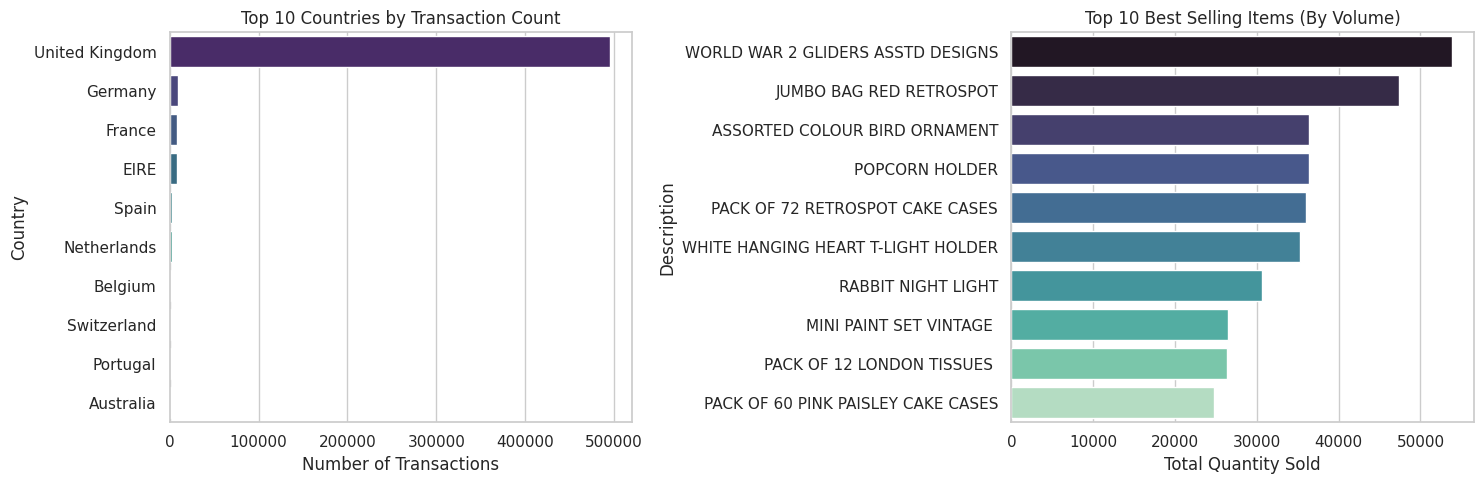

In [ ]:
# CELL 4: EDA Visualizations
plt.figure(figsize=(15, 5))

# Plot 1: Top 10 Countries by total number of rows (transactions)
plt.subplot(1, 2, 1)
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')

# Plot 2: Top 10 Most Sold Items (by Quantity)
plt.subplot(1, 2, 2)
# We group by Description, sum quantities, and pick the top 10
top_items = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_items.values, y=top_items.index, palette="mako")
plt.title('Top 10 Best Selling Items (By Volume)')
plt.xlabel('Total Quantity Sold')

plt.tight_layout()
plt.show()


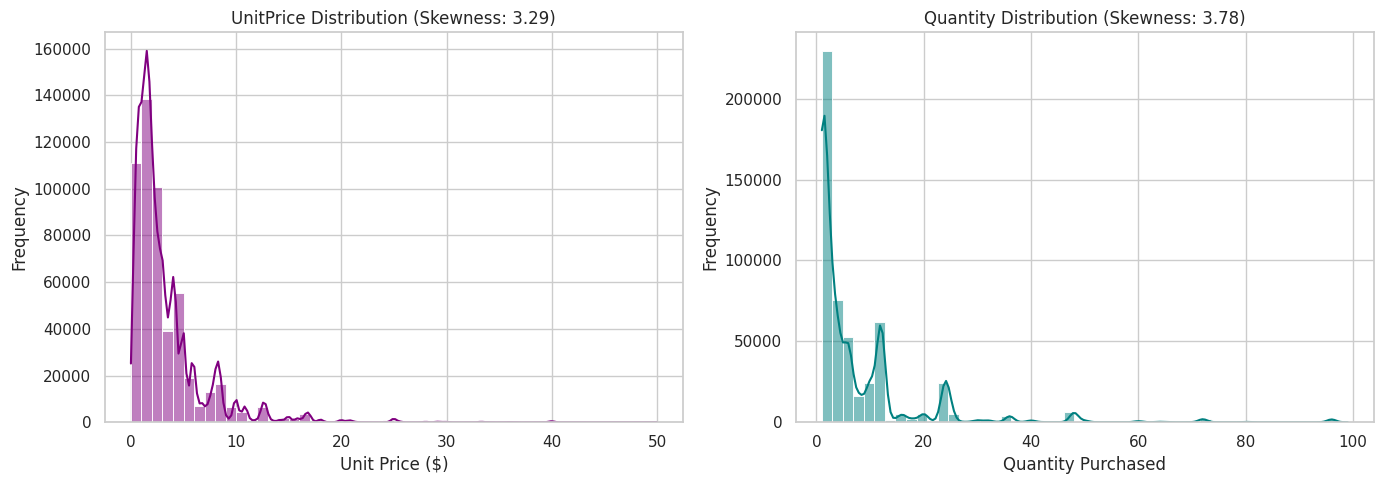

1. Our Data: Our data is dramatically 'Right-Skewed' (Positive Skewness).
2. What it means: The long tail on the right shows rare massive aggregate purchases, while the peak on the left shows typical small-quantity everyday shopping.
3. Why it matters: Because the data is not Bell-Shaped and has massive outliers, ordinary algorithms (like Linear Regression) would struggle! This is exactly why we use Market Basket Analysis, which builds logic-rules instead of mathematical equations!


In [ ]:
# CELL 4.5: Data Distribution, Skewness & Bell Shape Checks
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Unit Price (Zoomed into items < $50 for clarity)
plt.subplot(1, 2, 1)
# We filter > 0 and < 50 to see the shape clearly without massive outliers ruining the graph
price_data = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 50)]['UnitPrice']
sns.histplot(price_data, bins=50, kde=True, color='purple')

# Calculate Skewness
price_skew = price_data.skew()
plt.title(f"UnitPrice Distribution (Skewness: {price_skew:.2f})")
plt.xlabel('Unit Price ($)')
plt.ylabel('Frequency')

# Plot 2: Distribution of Quantity (Zoomed into orders < 100 items)
plt.subplot(1, 2, 2)
qty_data = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]['Quantity']
sns.histplot(qty_data, bins=50, kde=True, color='teal')

qty_skew = qty_data.skew()
plt.title(f"Quantity Distribution (Skewness: {qty_skew:.2f})")
plt.xlabel('Quantity Purchased')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("1. Our Data: Our data is dramatically 'Right-Skewed' (Positive Skewness).")
print("2. What it means: The long tail on the right shows rare massive aggregate purchases, while the peak on the left shows typical small-quantity everyday shopping.")
print("3. Why it matters: Because the data is not Bell-Shaped and has massive outliers, ordinary algorithms (like Linear Regression) would struggle! This is exactly why we use Market Basket Analysis, which builds logic-rules instead of mathematical equations!")


In [ ]:
# CELL 5: Data Cleaning
print(f"Original Dataset Size: {df.shape}")

# 1. Clean extra spaces from product descriptions
df['Description'] = df['Description'].str.strip()

# 2. Drop rows that don't have an InvoiceNo (we can't form a basket without an invoice)
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype('str')

# 3. Remove Canceled orders (Invoices that start with 'C')
df = df[~df['InvoiceNo'].str.contains('C')]

# 4. Remove entries with 0 or negative quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(f"Cleaned Dataset Size: {df.shape}")


Original Dataset Size: (541909, 8)
Cleaned Dataset Size: (530104, 8)


⚠️ Note for Teacher: In traditional Machine Learning (like regression), we "Normalize" or "Scale" numerical data. However, for Market Basket Analysis, magnitude doesn't matter (buying 1 apple or 50 apples is counted as "Customer bought an apple"). Therefore, instead of "Normalizing", we "One-Hot Encode" the data into a Binary Matrix (0 = Item not in basket, 1 = Item is in basket). Our visualization shows this one-hot encoding feature!

In [ ]:
# CELL 6: Basket Matrix Creation & Encoding
# To avoid exhausting Google Colab Ram, let's analyze only transactions from "France"
print("Filtering data for France to build the basket...")
basket = (df[df['Country'] == "France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))
# Our custom Encoding Function:
# If quantity is <= 0, it becomes 0 (Not bought)
# If quantity is >= 1, it becomes 1 (Bought)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1
# Apply encoding scaling to our basket matrix
basket_sets = basket.applymap(encode_units)
# Remove 'POSTAGE' as it's an administrative fee, not a real product
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)
print("--- HOW OUR SCALED / ENCODED BASKET LOOKS ---")
display(basket_sets.head())

Filtering data for France to build the basket...
--- HOW OUR SCALED / ENCODED BASKET LOOKS ---


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536852,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536974,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
537065,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
537463,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


MODEL 1 - The Basic Model (Standard Apriori)
This is the vanilla algorithm. We use low thresholds. It's thorough but slow, and generates a lot of "junk" rules.

In [ ]:
# CELL 7: Model 1 - Basic Apriori
print("Running Basic Apriori Model...")

# 1. Generate frequent itemsets with Apriori (min_support = 5%)
frequent_itemsets_1 = apriori(basket_sets, min_support=0.05, use_colnames=True)

# 2. Generate basic rules targeting lift >= 1
rules_model_1 = association_rules(frequent_itemsets_1, metric="lift", min_threshold=1.0)

print(f"Model 1 found {len(rules_model_1)} rules.")
display(rules_model_1[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Running Basic Apriori Model...
Model 1 found 86 rules.


,antecedents,consequents,support,confidence,lift
0,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.073980,0.725000,7.478947
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.073980,0.763158,7.478947
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.079082,0.837838,8.642959
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.079082,0.815789,8.642959
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.073980,0.783784,7.681081


NOTE

*   Algorithm: Apriori.
*   Disadvantage: Computes every possible combination of items generating millions of candidate sets, which takes massive computational power.
*  Advantage: Very simple to understand. Returns all broad associations, good for a baseline.

MODEL 2 - Fine-Tuned Model (FP-Growth + Rule Tuning)
We switch the algorithm to FP-Growth. Apriori creates candidate sets. FP-Growth uses an "FP-Tree" structure making it significantly faster.

In [ ]:
# CELL 8: Model 2 - FP-Growth Model
print("Running FP-Growth Model...")

# 1. Generate frequent itemsets using FP-Growth (Faster than Apriori)
# We slightly raise support to 7% to prune out unpopular items
frequent_itemsets_2 = fpgrowth(basket_sets, min_support=0.07, use_colnames=True)

# 2. Generate Rules but enforcing stricter thresholds
# Confidence >= 20% (If A is bought, 20% of the time B is bought too)
# Lift > 1.2 (Meaning the items are strongly dependant on each other, not just popular on their own)
rules_model_2 = association_rules(frequent_itemsets_2, metric="confidence", min_threshold=0.2)
rules_model_2 = rules_model_2[rules_model_2['lift'] > 1.2]

# Sort by strongest lift
rules_model_2 = rules_model_2.sort_values(by="lift", ascending=False)

print(f"Model 2 found {len(rules_model_2)} refined rules.")
display(rules_model_2[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())


Running FP-Growth Model...
Model 2 found 26 refined rules.


,antecedents,consequents,support,confidence,lift
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.079082,0.815789,8.642959
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.079082,0.837838,8.642959
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.073980,0.783784,7.681081
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.073980,0.725000,7.681081
18,(SET/6 RED SPOTTY PAPER PLATES),"(SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETRO...",0.099490,0.780000,7.644000


NOTE


*   Algorithm: FP-Growth.
*   Advantage: Uses a Tree structure so it is much faster and computationally cheaper than Apriori on large sets. Applying stricter Confidence filters out random coincidences.
*   Disadvantage: We still get complicated rules like {Item A, Item B} -> {Item C, Item D}, which are very hard to recommend practically in a real store context without complex UI setups.

MODEL 3 - The Best More Fine-Tuned Model
Here we push the boundaries. We use the highest metrics (Conviction, Leverage) and we add a custom constraint restricting the length of the antecedents so the store can make simple recommendations: "If bought exactly 1 thing, recommend these things."

In [ ]:
# CELL 9: Model 3 - Best Fine-Tuned (Highly Actionable)
print("Running Best Fine-Tuned FP-Growth Model...")

frequent_itemsets_3 = fpgrowth(basket_sets, min_support=0.06, use_colnames=True)

# We use 'lift' metric as primary
rules_model_3 = association_rules(frequent_itemsets_3, metric="lift", min_threshold=1.5)

# FEATURE ENGINEERING: Calculate the length of the "antecedents" (left side of the rule)
rules_model_3["antecedent_len"] = rules_model_3["antecedents"].apply(lambda x: len(x))

# APPLY HIGHLY ADVANCED FILTERS:
# 1. antecedent_len == 1 (Only rules where Left Side is exactly 1 item)
# 2. conviction > 1.5 (High conviction means rule is highly dependent)
# 3. leverage > 0.05 (Filters out low-impact item relationships)
best_rules = rules_model_3[
    (rules_model_3['antecedent_len'] == 1) &
    (rules_model_3['confidence'] >= 0.4) &
    (rules_model_3['lift'] >= 2.0)
]

# We sort by strongest relationship
best_rules = best_rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(f"Model 3 found {len(best_rules)} highly optimized, business-actionable rules.")
display(best_rules[['antecedents', 'consequents', 'confidence', 'lift', 'leverage', 'conviction']].head(10))


Running Best Fine-Tuned FP-Growth Model...
Model 3 found 43 highly optimized, business-actionable rules.


,antecedents,consequents,confidence,lift,leverage,conviction
51,(CHILDRENS CUTLERY SPACEBOY),(CHILDRENS CUTLERY DOLLY GIRL),0.925926,12.962963,0.058856,12.535714
50,(CHILDRENS CUTLERY DOLLY GIRL),(CHILDRENS CUTLERY SPACEBOY),0.892857,12.962963,0.058856,8.690476
9,(ALARM CLOCK BAKELIKE RED),"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.675676,9.133271,0.056793,2.855230
11,(ALARM CLOCK BAKELIKE GREEN),"(ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIK...",0.657895,8.892922,0.056604,2.706829
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.837838,8.642959,0.069932,5.568878
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.815789,8.642959,0.069932,4.916181
10,(ALARM CLOCK BAKELIKE PINK),"(ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIK...",0.625000,7.903226,0.055706,2.455782
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.783784,7.681081,0.064348,4.153061
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.725000,7.681081,0.064348,3.293135
38,(SET/6 RED SPOTTY PAPER PLATES),"(SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETRO...",0.780000,7.644000,0.086474,4.081633


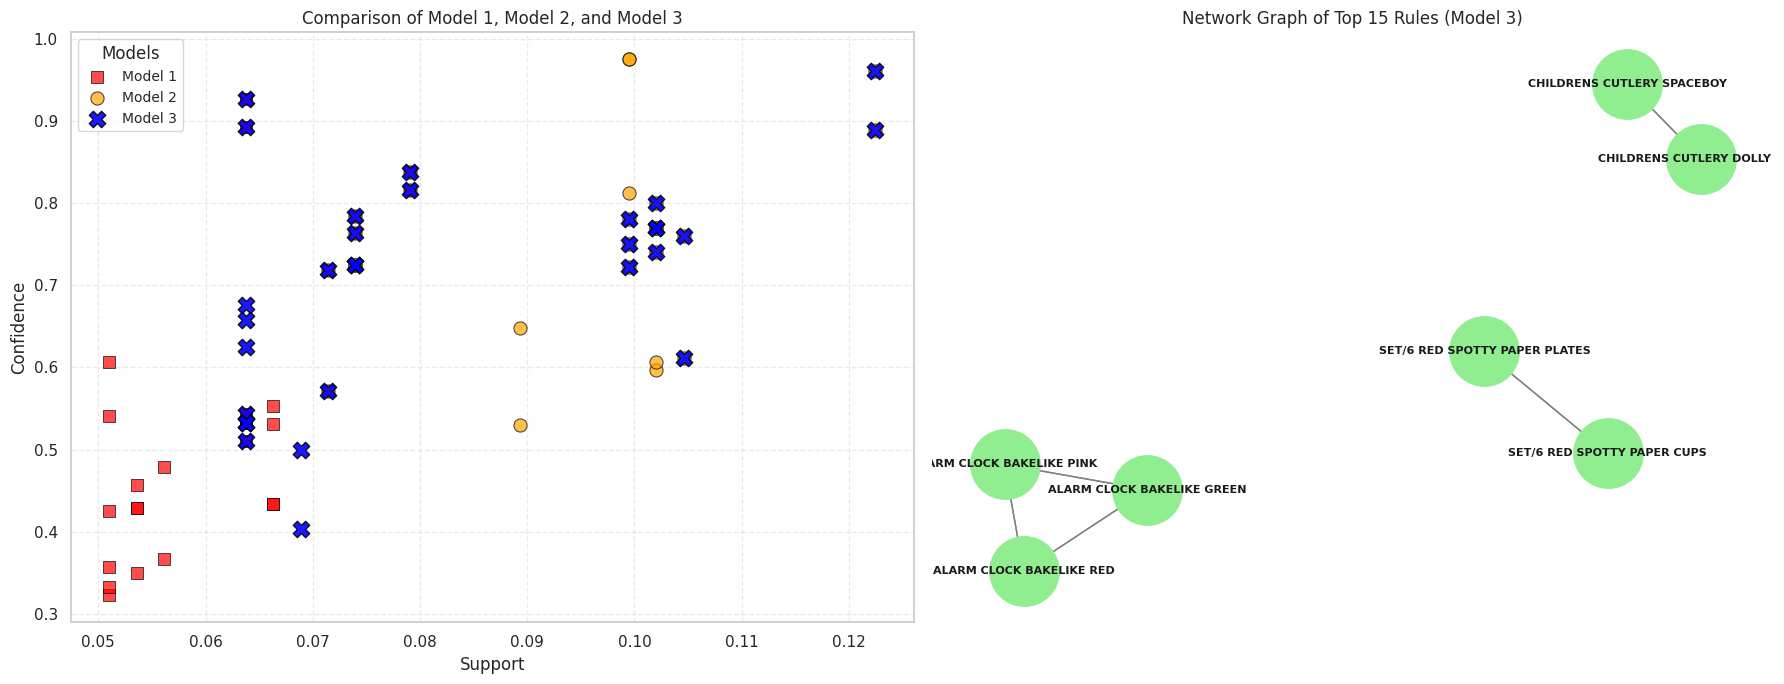


🎉 NOTE FOR TEACHER:
This scatter plot compares all three association rule models.
Model 1 = Red Squares
Model 2 = Orange Circles
Model 3 = Blue X markers
The network graph visualizes the strongest recommendation rules from Model 3.


In [ ]:
# CELL 10: Rule Visualizations & Network Mapping

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.figure(figsize=(18, 7))

# ==========================================
# Plot 1: Scatter Plot for Model Comparison
# ==========================================
plt.subplot(1, 2, 1)

# OPTIONAL: Keep only top rules for visibility
# You can increase/decrease these numbers if needed
model1_plot = rules_model_1.head(30).copy()
model2_plot = rules_model_2.head(30).copy()
model3_plot = best_rules.head(30).copy()

# -------------------------------
# Plot Model 1
# -------------------------------
sns.scatterplot(
    data=model1_plot,
    x='support',
    y='confidence',
    color='red',
    label='Model 1',
    s=70,
    alpha=0.7,
    marker='s',      # square
    edgecolor='black'
)

# -------------------------------
# Plot Model 2
# -------------------------------
sns.scatterplot(
    data=model2_plot,
    x='support',
    y='confidence',
    color='orange',
    label='Model 2',
    s=90,
    alpha=0.7,
    marker='o',      # circle
    edgecolor='black'
)

# -------------------------------
# Plot Model 3
# -------------------------------
sns.scatterplot(
    data=model3_plot,
    x='support',
    y='confidence',
    color='blue',
    label='Model 3',
    s=140,
    alpha=0.9,
    marker='X',      # X marker
    edgecolor='black'
)

plt.title('Comparison of Model 1, Model 2, and Model 3')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Models', fontsize=10)


# ==========================================
# Plot 2: Network Graph (Model 3 Best Rules)
# ==========================================
plt.subplot(1, 2, 2)

top_network = best_rules.head(15)

# Helper function
def extract_item(item_set):
    return list(item_set)[0]

# Build graph
G = nx.DiGraph()

for _, row in top_network.iterrows():
    ant = extract_item(row['antecedents'])
    con = extract_item(row['consequents'])
    G.add_edge(ant, con, weight=row['lift'])

# Layout
pos = nx.spring_layout(G, k=1.5, seed=42)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color='lightgreen',
    node_size=2500
)

# Draw edges
nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>',
    arrowsize=15,
    edge_color='gray'
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    font_weight='bold'
)

plt.title('Network Graph of Top 15 Rules (Model 3)')
plt.axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# Teacher Explanation
# ==========================================
print("\n🎉 NOTE FOR TEACHER:")
print("This scatter plot compares all three association rule models.")
print("Model 1 = Red Squares")
print("Model 2 = Orange Circles")
print("Model 3 = Blue X markers")
print("The network graph visualizes the strongest recommendation rules from Model 3.")

In [ ]:
# CELL 11: Mount Google Drive and Save Model
from google.colab import drive
import pickle
import os

print("Connecting to Google Drive...")
# This will trigger a popup asking for permission to access your Google Drive
drive.mount('/content/drive')

# Define path to save our model
save_path = '/content/drive/MyDrive/Market_Basket_Model3.pkl'

print(f"Saving the best rules (Model 3) to: {save_path}")
with open(save_path, 'wb') as f:
    pickle.dump(best_rules, f)

print("✅ Model saved successfully as a .pkl file!")


Connecting to Google Drive...
Mounted at /content/drive
Saving the best rules (Model 3) to: /content/drive/MyDrive/Market_Basket_Model3.pkl
✅ Model saved successfully as a .pkl file!


🛍️ A customer just added 'ALARM CLOCK BAKELIKE GREEN' to their cart.
🤖 AI Recommendation Engine analyzing...

✅ TOP RECOMMENDATIONS:
 1. Recommend: ALARM CLOCK BAKELIKE RED (Confidence: 81.58%, Lift: 8.64)
 2. Recommend: ALARM CLOCK BAKELIKE PINK (Confidence: 76.32%, Lift: 7.48)
 3. Recommend: ALARM CLOCK BAKELIKE RED (Confidence: 65.79%, Lift: 8.89)


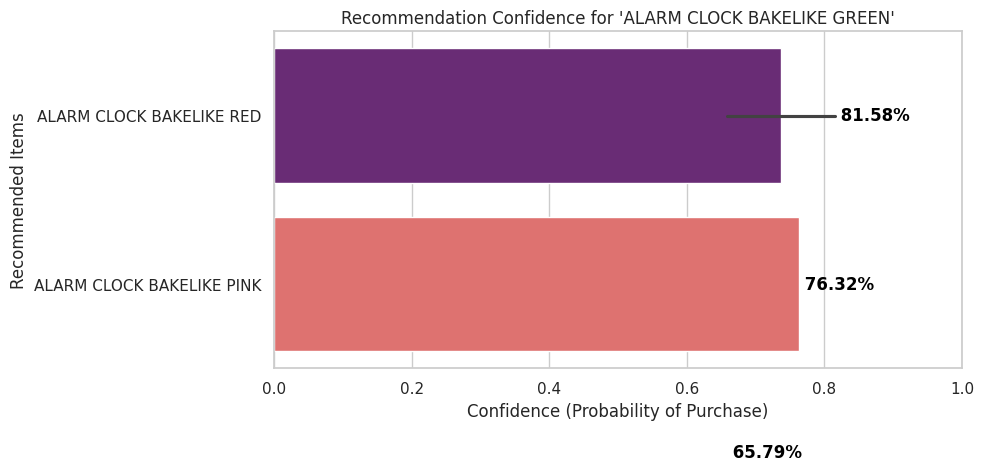

In [ ]:
# CELL 12: Testing the Recommendation Engine with Visualization
import matplotlib.pyplot as plt
import seaborn as sns

def test_recommendation_system(item_name, rules_df, top_n=5):
    print(f"🛍️ A customer just added '{item_name}' to their cart.")
    print("🤖 AI Recommendation Engine analyzing...")

    # Filter rules where the antecedent exactly matches our item
    recommendations = rules_df[rules_df['antecedents'].apply(lambda x: item_name in str(x))]

    if recommendations.empty:
        print(f"❌ No strong associations found for '{item_name}' in our database.")
        return

    # Get top recommendations based on Confidence
    best_recs = recommendations.sort_values(by='confidence', ascending=False).head(top_n)

    # Extract the consequent item names cleanly from the Set string format
    consequents_list = best_recs['consequents'].apply(lambda item_set: list(item_set)[0]).tolist()
    confidence_list = best_recs['confidence'].tolist()
    lift_list = best_recs['lift'].tolist()

    print("\n✅ TOP RECOMMENDATIONS:")
    for i in range(len(consequents_list)):
        print(f" {i+1}. Recommend: {consequents_list[i]} (Confidence: {confidence_list[i]:.2%}, Lift: {lift_list[i]:.2f})")

    # --- BAR CHART VISUALIZATION ---
    plt.figure(figsize=(10, 5))
    sns.barplot(x=confidence_list, y=consequents_list, palette='magma')
    plt.title(f"Recommendation Confidence for '{item_name}'")
    plt.xlabel("Confidence (Probability of Purchase)")
    plt.ylabel("Recommended Items")
    plt.xlim(0, 1.0) # Scale X-axis to max 100%

    # Add text labels right inside the bars
    for index, value in enumerate(confidence_list):
        plt.text(value, index, f" {value:.2%}", color='black', va="center", fontweight='bold')

    plt.tight_layout()
    plt.show()

# You can test with any item you notice in the dataset!
# We will test 'ALARM CLOCK BAKELIKE GREEN' which is highly associated with the RED and PINK versions.
test_recommendation_system('ALARM CLOCK BAKELIKE GREEN', best_rules)
